In [1]:

import numpy as np
import pandas as pd

from sklearn.svm import OneClassSVM
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.ensemble import IsolationForest

from scikit_posthocs import outliers_gesd

import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

from statistics import fmean, mean, stdev
from pathlib import Path

In [2]:
nab_data_folder = Path('data/nab_data_corpus')
nab_data = {}
for dir in nab_data_folder.glob('*'):
    if (dir / dir.name).exists():
        nab_data[dir.name] = {}
        sub_dir = dir / dir.name
        for file in sub_dir.rglob('*.csv'):
           if file.is_file():
               nab_data[dir.name][file.name[:-4]] = {}
               nab_data[dir.name][file.name[:-4]]['path'] = file
               df = pd.read_csv(file)
               df['timestamp'] = pd.to_datetime(df['timestamp'])
               nab_data[dir.name][file.name[:-4]]['df'] = df

nab_data['realAdExchange']['exchange-2_cpc_results']

{'path': PosixPath('data/nab_data_corpus/realAdExchange/realAdExchange/exchange-2_cpc_results.csv'),
 'df':                timestamp     value
 0    2011-07-01 00:00:01  0.081965
 1    2011-07-01 01:00:01  0.098972
 2    2011-07-01 02:00:01  0.065314
 3    2011-07-01 03:00:01  0.070663
 4    2011-07-01 04:00:01  0.102490
 ...                  ...       ...
 1619 2011-09-07 11:00:01  0.094662
 1620 2011-09-07 12:00:01  0.097657
 1621 2011-09-07 13:00:01  0.096201
 1622 2011-09-07 14:00:01  0.085386
 1623 2011-09-07 15:00:01  0.109327
 
 [1624 rows x 2 columns]}

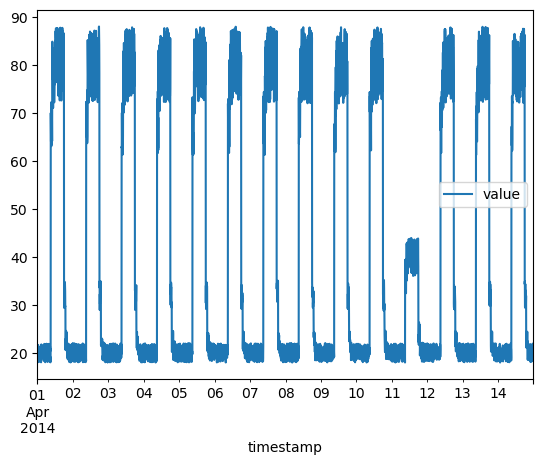

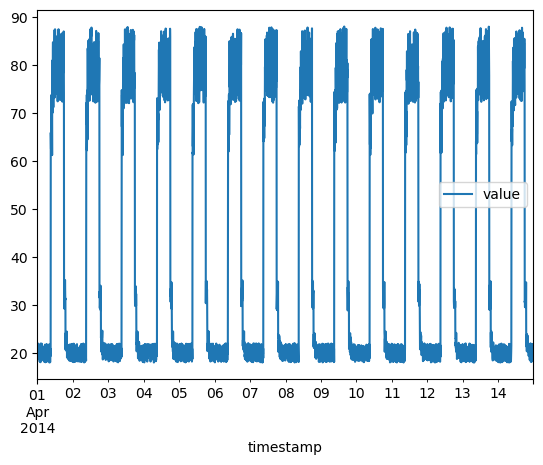

In [5]:
nab_data['artificialWithAnomaly']['art_daily_jumpsdown']['df'].plot(x='timestamp', y='value')
nab_data['artificialNoAnomaly']['art_daily_small_noise']['df'].plot(x='timestamp', y='value');

<Axes: xlabel='timestamp'>

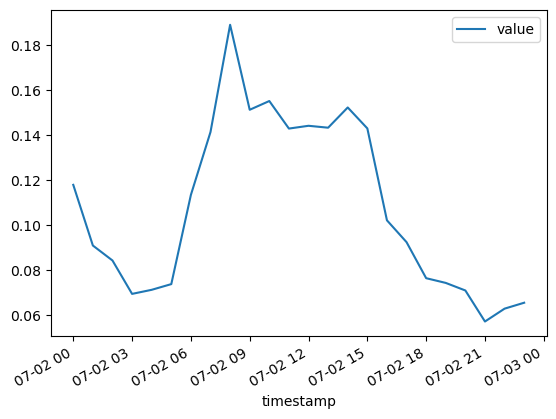

In [23]:
df_cpc = pd.read_csv('data/nab_data_corpus/realAdExchange/realAdExchange/exchange-2_cpc_results.csv')
df_cpc['timestamp'] = pd.to_datetime(df_cpc['timestamp'])
daily_cpc = {}
day = 0
length = df_cpc.index.size
for i in range(0, length):
    if (i+1)%24 == 0 :
        day+=1
        daily_cpc[day] = df_cpc[i-23:i+1].reset_index()
        if i+25>length:
            daily_cpc[day+1] = df_cpc[i+1:length].reset_index()
            break
daily_cpc[2].plot(x='timestamp', y='value')

(2011-07-02 00:00:01,0.04506896095496646)	z-score: 3.597300951727539
(2011-07-06 12:00:01,0.03836769482139772)	z-score: 3.047080458463477
(2011-07-14 05:00:01,0.0456550621028486)	z-score: 3.645423926738921
(2011-07-14 13:00:01,0.05963190883546016)	z-score: 4.793020119788226
(2011-07-19 06:00:01,0.06001560862780035)	z-score: 4.8245245377293635
(2011-08-04 08:00:01,0.041025152808857546)	z-score: 3.2652762166298497
(2011-08-09 08:00:01,0.04347709553879932)	z-score: 3.4665977447461085
(2011-08-10 21:00:01,0.04007171394559561)	z-score: 3.1869922638387176
(2011-08-12 08:00:01,0.055410692251533056)	z-score: 4.4464289197539255
(2011-08-13 12:00:01,0.03904026347400255)	z-score: 3.102303016173344
(2011-08-13 14:00:01,0.04442919613258911)	z-score: 3.5447718163186166
(2011-08-15 08:00:01,0.04803368900179816)	z-score: 3.8407257159150228
(2011-08-16 07:00:01,0.050863546786742944)	z-score: 4.073076694859096
(2011-08-16 14:00:01,0.05426289983806931)	z-score: 4.352187190607071
(2011-08-19 13:00:01,0.05

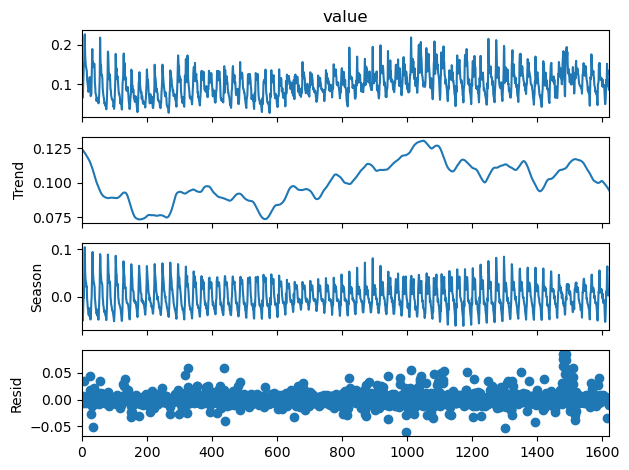

In [24]:


stl = STL(df_cpc["value"], period=24, robust=True)
result = stl.fit()
result_plot = result.plot()
z_score  = lambda x: (x-fmean(result.resid))/stdev(result.resid)
threshold = 3

for i, z in enumerate( z_score(result.resid) ):
    if z >= 3:
       print(f"({df_cpc['timestamp'][i]},{result.resid[i]})\tz-score: {z}")

In [40]:
def STL_outliers(nab_df, period, stat_test='zscore', threshold=5, debug=False):

    stl = STL(nab_df["value"], period=period, robust=True)
    result = stl.fit()
    outliers = []
    if stat_test == 'zscore':
        anom_score = lambda x: (x-fmean(result.resid))/stdev(result.resid)
        for i, score in enumerate(anom_score(result.resid)):
            if score > threshold:
               outliers.append(np.array([nab_df['timestamp'][i], nab_df['value'][i]]))
        outliers = np.array(outliers)
        nab_df['timestamp'] = pd.to_datetime(nab_df['timestamp'])
        nab_df.plot(x='timestamp', y='value')
        plt.scatter(outliers[:, 0], outliers[:, 1], color='r')
        return outliers
    elif stat_test=='gesd':
         outlier_indexes = outliers_gesd(result.resid, threshold, hypo=True, report=True)
         if not debug:
            return nab_df[ outlier_indexes ]
         else:
             return outlier_indexes

    else:
        return np.array(outliers)


H0: no outliers in the data
Ha: up to 5 outliers in the data
Significance level:  α = 0.05
Reject H0 if Ri > Critical Value (λi)

Summary Table for Two-Tailed Test
---------------------------------------
      Exact           Test     Critical
  Number of      Statistic    Value, λi
Outliers, i      Value, Ri          5 %
---------------------------------------
          1          6.997        4.157 *
          2          7.096        4.157 *
          3           6.98        4.157 *
          4          6.478        4.157 *
          5          6.348        4.156 *


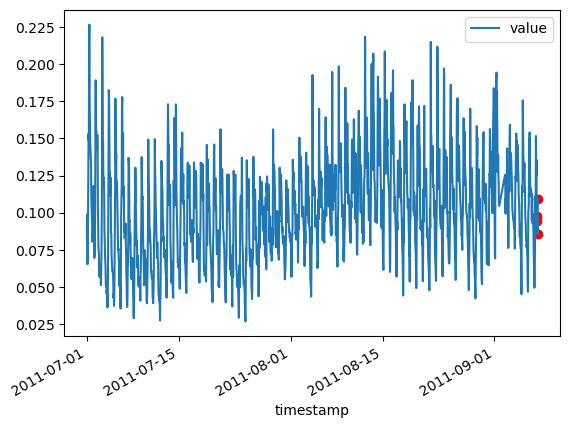

In [52]:
daily = 24
threshold = 4
nab_df = nab_data['realAdExchange']['exchange-2_cpc_results']['df']
# nab_df = nab_data['artificialWithAnomaly']['art_daily_jumpsup']['df']
nab_df_outliers = STL_outliers(nab_df, daily, 'gesd', 5)
outliers = nab_df_outliers.to_numpy()
nab_df.plot(x='timestamp', y='value')
plt.scatter(outliers[:,0], outliers[:,1], color='r')